<h1 align="center">EN3160 Assignment 1</h1>
<h2 align="center">Intensity Transformations and Neighborhood Filtering</h2>

**Name:** Anthony C.S.B.  
**Index Number:** 230045X

<h2 align="left">Question 1</h2>

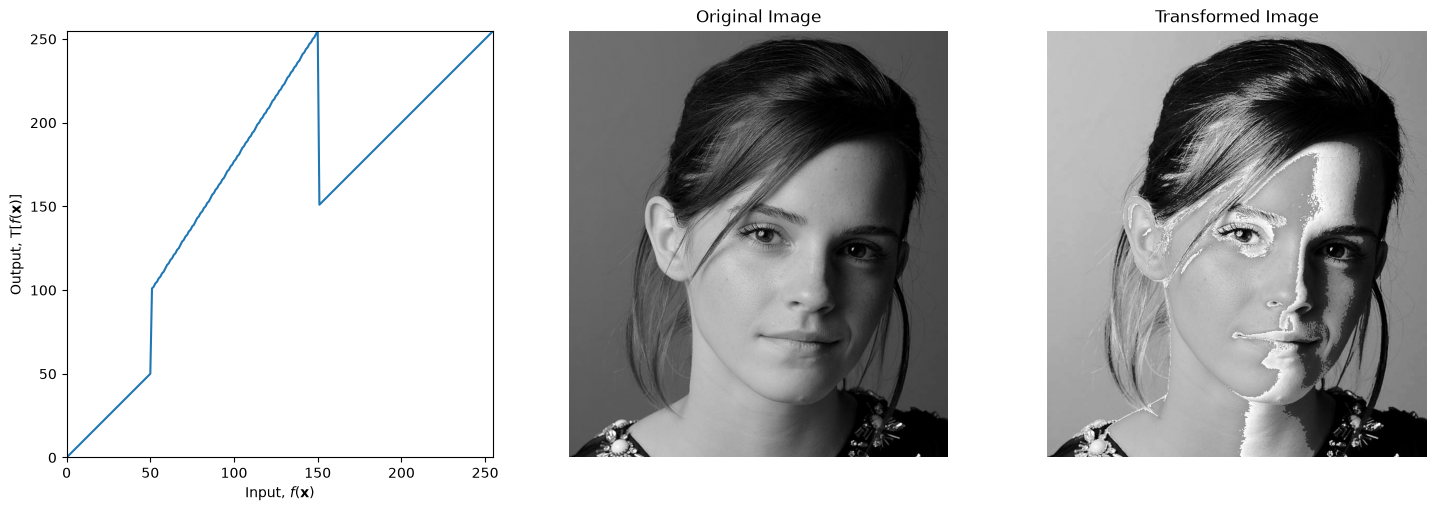

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def  intensity_transform(im, breakpoints):

    #First window is handled differently from the rest
    transform  = np.linspace(breakpoints[0,1],breakpoints[1,1],breakpoints[1,0]-breakpoints[0,0]+1).astype('uint8')
        
    for i in range(2,len(breakpoints)):
        if (breakpoints[i-1,1]<255):
            window = np.linspace(breakpoints[i-1,1]+1,breakpoints[i,1],breakpoints[i,0]-breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform, window), axis=0).astype('uint8')   
        else:
            window = np.linspace(breakpoints[i-1,1],breakpoints[i,1],breakpoints[i,0]-breakpoints[i-1,0]).astype('uint8')
            transform = np.concatenate((transform, window), axis=0).astype('uint8')   
      
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].plot(transform)
    ax[0].set_xlabel(r'Input, $f(\mathbf{x})$')
    ax[0].set_ylabel(r'Output, $\mathrm{T}[f(\mathbf{x})]$')
    ax[0].set_xlim(0,255)
    ax[0].set_ylim(0,255)
    ax[0].set_aspect('equal') 

    img_original = cv.imread(im, cv.IMREAD_GRAYSCALE)
    assert img_original is not None

    image_transformed = cv.LUT(img_original, transform)
    
    ax[1].imshow(img_original, cmap='gray')
    ax[1].set_title('Original Image')
    ax[1].axis('off')

    ax[2].imshow(image_transformed, cmap='gray')
    ax[2].set_title('Transformed Image')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show(block=False)

intensity_transform("emma.jpg", np.array([(0,0),(50,50),(50,100),(150,255),(150,150),(255,255)]))


<h2 align="left">Question 2</h2>

After searching how gray and white matter appear in a proton density image, I learnt the following and intensity windowing was applied accordingly.
- Gray Matter: Appears lighter or brighter gray because it has a higher proton (water) density and higher signal intensity.
- White Matter: Appears darker gray because it contains more myelin and less free water, resulting in a lower signal.
- Cerebrospinal Fluid (CSF): Appears very bright (hyperintense) due to its high water content - A very bright coloured, butterfly shaped patch which appears right in the middle of the given image. 

To determine the correct intensity ranges of gray and white matter to apply appropriate intensity windowing, I plotted the histogram of the given image first and then I compared it with a reference image of normal proton density image with named regions to clarify the intensity ranges.

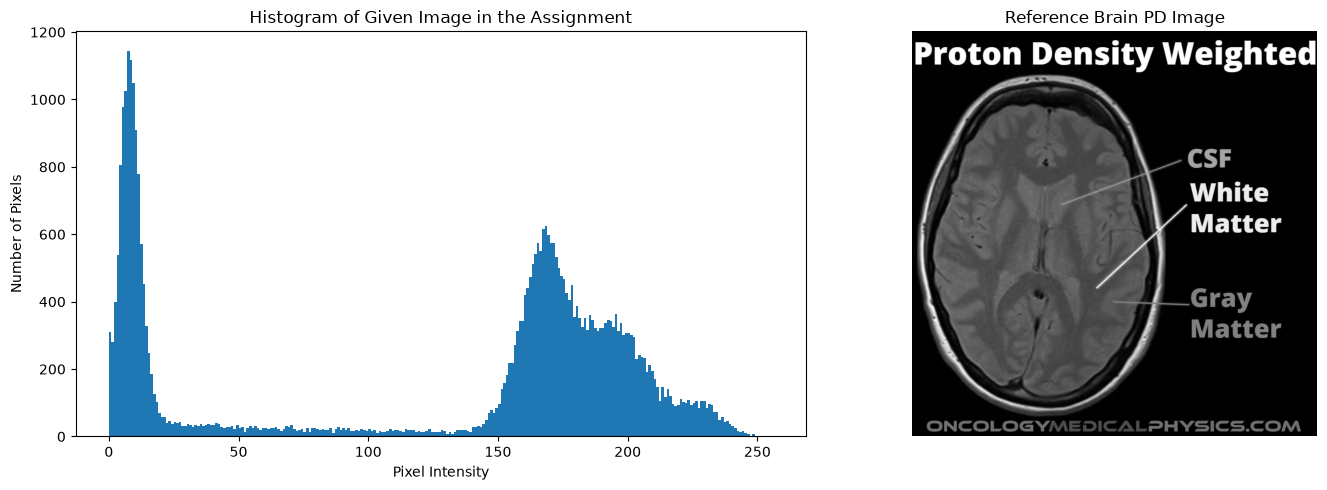

In [3]:
img1 = cv.imread("brain_PD_slice.jpg", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("Proton-Density-Weighted.jpg", cv.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(img1.ravel(), bins=256, range=[0, 256])
ax[0].set_xlabel("Pixel Intensity")
ax[0].set_ylabel("Number of Pixels")
ax[0].set_title("Histogram of Given Image in the Assignment")

ax[1].imshow(img2, cmap='gray')
ax[1].set_title("Reference Brain PD Image")
ax[1].axis('off')

plt.tight_layout()
plt.show(block=False)

According to above histogram and reference image:
- White Matter - Intensity range of 145-180
- Gray Matter - Intensity range of 180-215

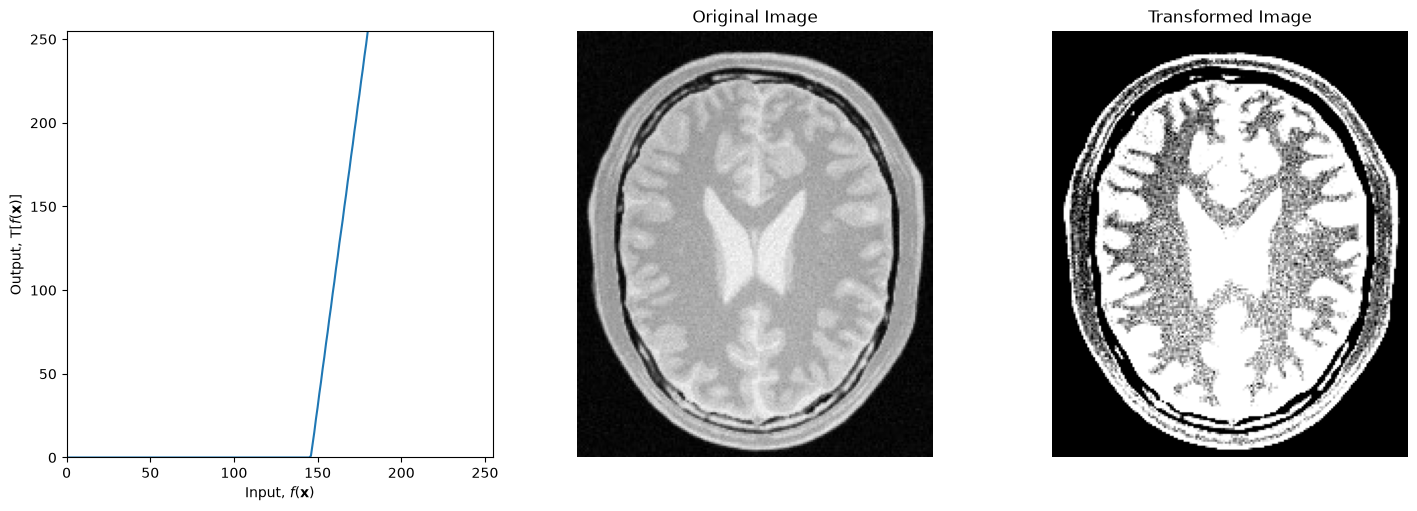

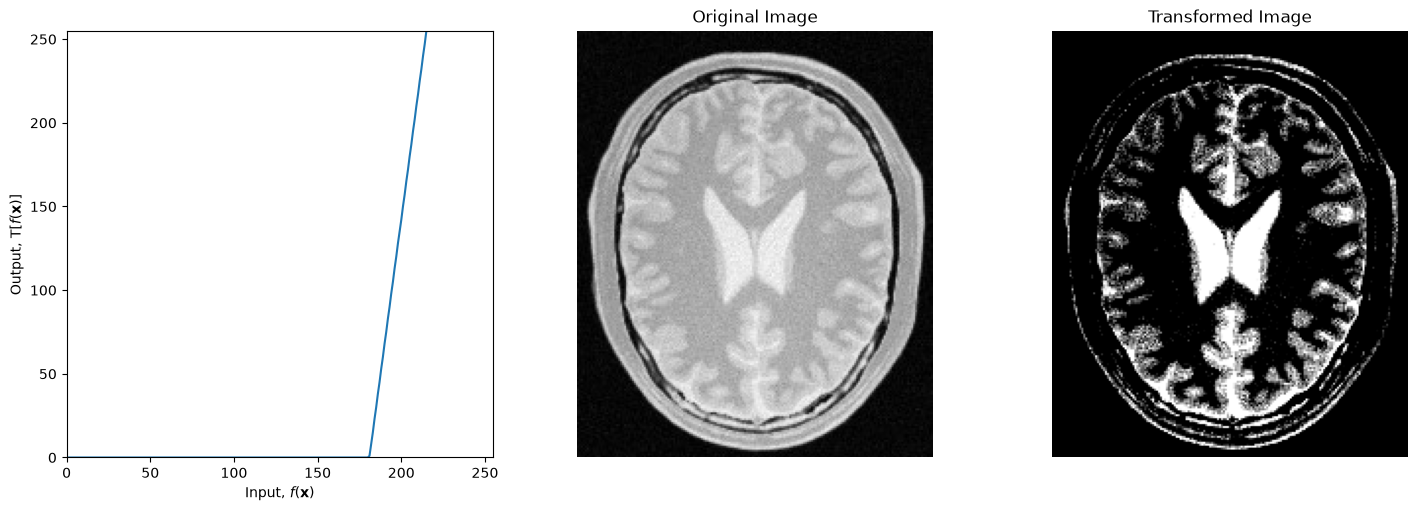

In [4]:
intensity_transform("brain_PD_slice.jpg", np.array([(0,0), (145,0), (180,255), (255,255)])) #White Matter - first row of images
intensity_transform("brain_PD_slice.jpg", np.array([(0,0), (180,0), (215,255), (255,255)])) #Gray Matter - second row of images

<h2 align="left">Question 3</h2>

In this question, L, a and b planes are lightness, Green-Red Axis and Blue-Yellow Axis respectively. Only L plane is used for gamma correction to change only the brightness and keep colours untouched. For the gamma value, **0.5** is used because the given image has more dark pixels and the variation of dark pixels are not very sensitive to bare eye.

- $\gamma$ = 0.5

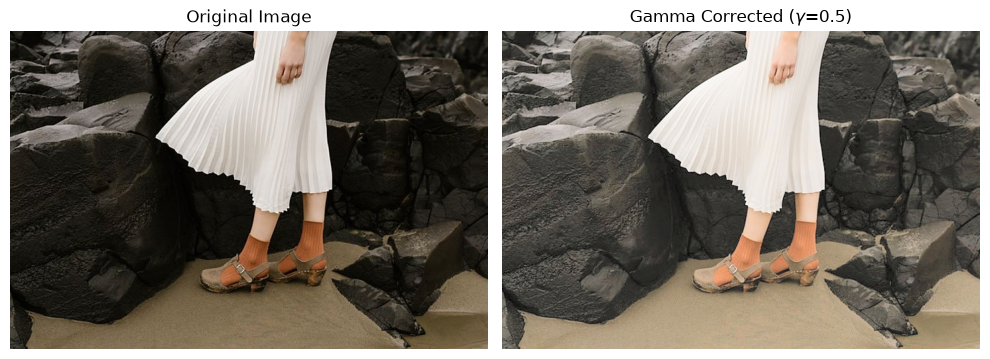

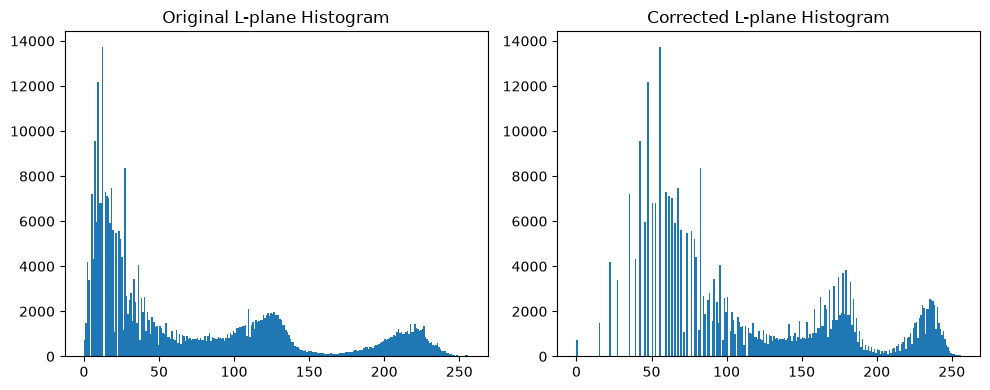

In [5]:
img_bgr = cv.imread('lady.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)
gamma = 0.5
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
L_corrected = cv.LUT(L, table)

img_lab_corrected = cv.merge((L_corrected, a, b))
img_corrected_rgb = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_corrected_rgb)
plt.title(rf'Gamma Corrected ($\gamma$={gamma})')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(L.ravel(), 256, range=[0, 256])
plt.title('Original L-plane Histogram')

plt.subplot(1, 2, 2)
plt.hist(L_corrected.ravel(), 256, range=[0, 256])
plt.title('Corrected L-plane Histogram')
plt.tight_layout()
plt.show()

<h2 align="left">Question 4</h2>

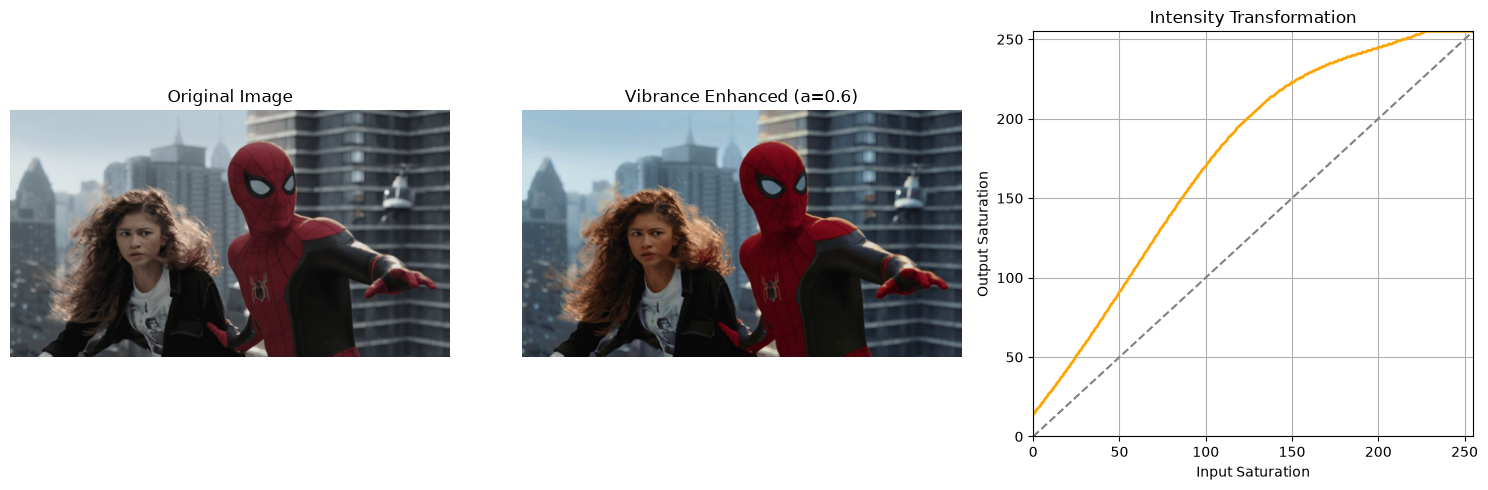

In [6]:
img_bgr = cv.imread('spider_man.jpg') 
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)
a = 0.6    
sigma = 70
x = np.arange(256) 

curve = x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2))
transform_curve = np.clip(curve, 0, 255).astype(np.uint8)

s_enhanced = cv.LUT(s, transform_curve)
img_hsv_enhanced = cv.merge((h, s_enhanced, v))
img_enhanced_rgb = cv.cvtColor(img_hsv_enhanced, cv.COLOR_HSV2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_enhanced_rgb)
plt.title(f'Vibrance Enhanced (a={a})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.plot(x, transform_curve, color='orange', linewidth=2)
plt.plot(x, x, linestyle='--', color='gray') # Reference line y=x
plt.title('Intensity Transformation')
plt.xlabel('Input Saturation')
plt.ylabel('Output Saturation')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

<h2 align="left">Question 5</h2>

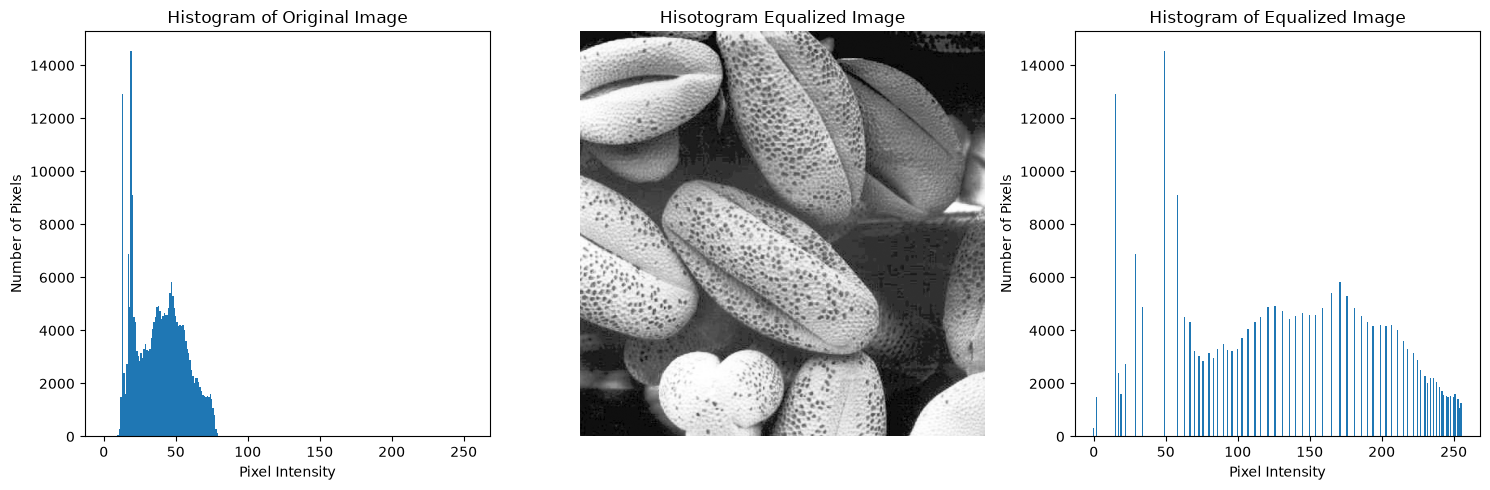

In [7]:
def histogram_equalization(im):

    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    height,width = img.shape[:2]
    hist1 = cv.calcHist([img], [0], None, [256], [0,256])

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].bar(np.arange(256), hist1.flatten(), width=1)
    ax[0].set_xlabel("Pixel Intensity")
    ax[0].set_ylabel("Number of Pixels")
    ax[0].set_title("Histogram of Original Image")

    cdf = 0
    mapping = np.arange(256)
    for k in range(256):
        cdf += hist1[k]
        mapping[k] = round(255*cdf/(height*width))

    equalized_img = mapping[img].astype(np.uint8)
    ax[1].imshow(equalized_img, cmap='gray')
    ax[1].set_title("Hisotogram Equalized Image")
    ax[1].axis('off')

    hist2 = cv.calcHist([equalized_img], [0], None, [256], [0,256])
    ax[2].bar(np.arange(256), hist2.flatten(), width=1)
    ax[2].set_xlabel("Pixel Intensity")
    ax[2].set_ylabel("Number of Pixels")
    ax[2].set_title("Histogram of Equalized Image")

    plt.tight_layout()
    plt.show(block=False)
    
    
histogram_equalization("shells.jpg")

<h2 align="left">Question 6</h2>

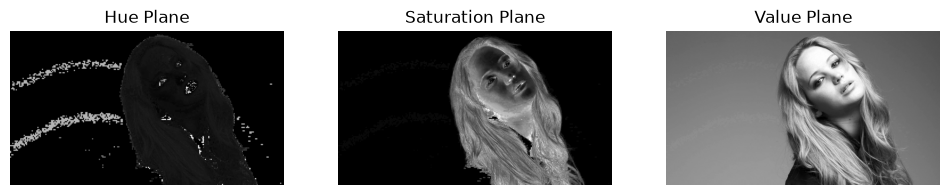

In [8]:
img_bgr = cv.imread('jennifer_lawrence.jpg')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

h, s, v = cv.split(img_hsv)

plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1), plt.imshow(h, cmap='gray'); plt.title('Hue Plane'); plt.axis('off');
plt.subplot(1, 3, 2), plt.imshow(s, cmap='gray'); plt.title('Saturation Plane'); plt.axis('off');
plt.subplot(1, 3, 3), plt.imshow(v, cmap='gray'); plt.title('Value Plane'); plt.axis('off');

**Plane Selection For Masking and Foreground Extraction:** 

After analyzing all three H,S,V planes, **saturation plane** can be used to extract the foreground mask since it shows a very clear distinction between background and foreground unlike other planes. Then using "bitwise-and" operator between the **value plane** and the **foreground mask**, foreground can be extracted while using "bitwise-and" operator between the **value plane** and the **inverse foreground mask**, background can be extracted. 

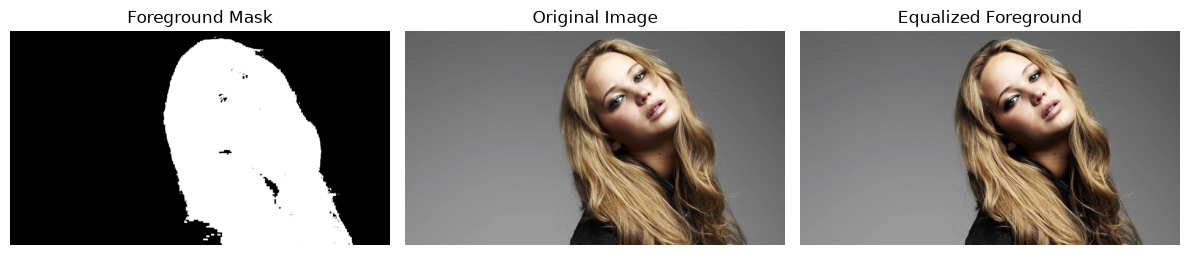

In [9]:
_, mask = cv.threshold(s, 13, 255, cv.THRESH_BINARY)
v_foreground = cv.bitwise_and(v, v, mask=mask) #Foreground only

hist, bins = np.histogram(v_foreground[mask == 255], bins=256, range=[0, 256])
cdf = hist.cumsum()
mapping = np.arange(256)
for k in range(len(cdf)):
    mapping[k] = round(255*cdf[k]/cdf.max())
v_equalized_foreground = mapping[v_foreground].astype(np.uint8)

mask_inv = cv.bitwise_not(mask)
v_background = cv.bitwise_and(v, v, mask=mask_inv) #Background only

v_final = cv.add(v_equalized_foreground, v_background)
img_hsv_final = cv.merge((h, s, v_final))
img_final_rgb = cv.cvtColor(img_hsv_final, cv.COLOR_HSV2RGB)

plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1), plt.imshow(mask, cmap='gray'); plt.title('Foreground Mask'); plt.axis('off');
plt.subplot(1, 3, 2), plt.imshow(img_rgb); plt.title('Original Image'); plt.axis('off');
plt.subplot(1, 3, 3), plt.imshow(img_final_rgb); plt.title('Equalized Foreground'); plt.axis('off');
plt.tight_layout()
plt.show(block=False)

<h2 align="left">Question 7</h2>

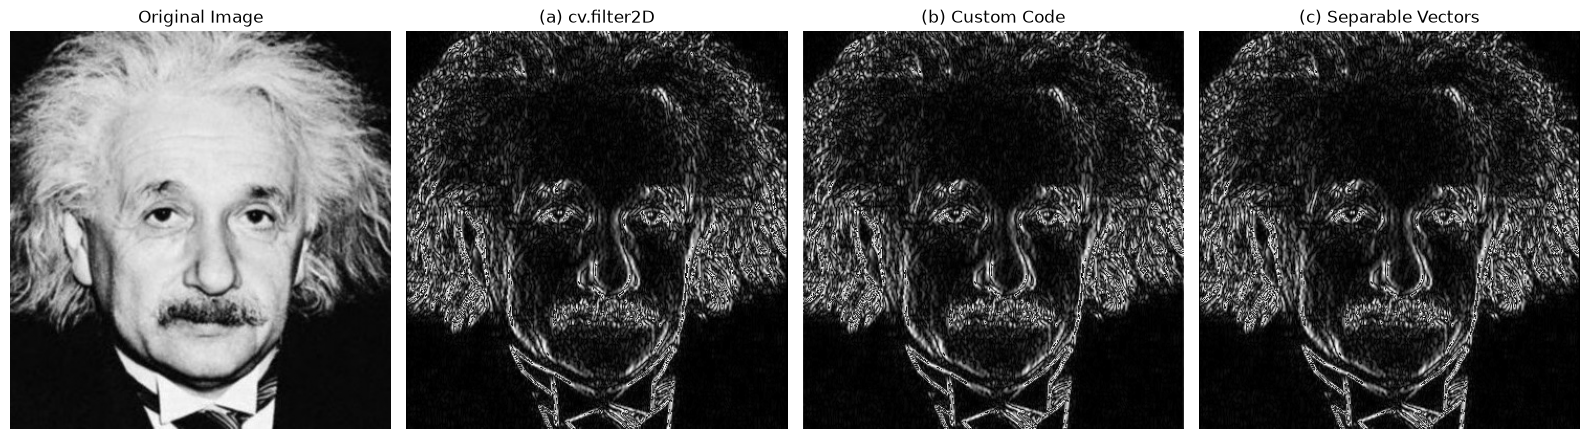

In [10]:
img = cv.imread('albert_einstein.jpg', cv.IMREAD_GRAYSCALE)

sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)

# (a) Using existing cv.filter2D
filtered_a_float = cv.filter2D(img, cv.CV_64F, sobel_x)
filtered_a = np.uint8(np.absolute(filtered_a_float))

# (b) Custom code for Sobel filtering
def sobel_filter2D(image):

    h, w = image.shape
    sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
    k_h, k_w = sobel_x.shape
    
    padded_img = np.pad(image, ((1,1), (1,1)), mode='constant') #Padding the outer boundary of the image

    output = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * sobel_x)
            
    return output

filtered_b_float = sobel_filter2D(img)
filtered_b = np.uint8(np.absolute(filtered_b_float))


# (c) Using separable property
sobel_x_col = np.array([[1], [2], [1]], dtype=np.float32)
sobel_x_row = np.array([[1, 0, -1]], dtype=np.float32)

filtered_c_step1 = cv.filter2D(img, cv.CV_64F, sobel_x_row)
filtered_c_step2 = cv.filter2D(filtered_c_step1, cv.CV_64F, sobel_x_col)
filtered_c = np.uint8(np.absolute(filtered_c_step2))

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(filtered_a, cmap='gray')
plt.title('(a) cv.filter2D')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(filtered_b, cmap='gray')
plt.title('(b) Custom Code')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(filtered_c, cmap='gray')
plt.title('(c) Separable Vectors')
plt.axis('off')

plt.tight_layout()
plt.show()

<h2 align="left">Question 8</h2>

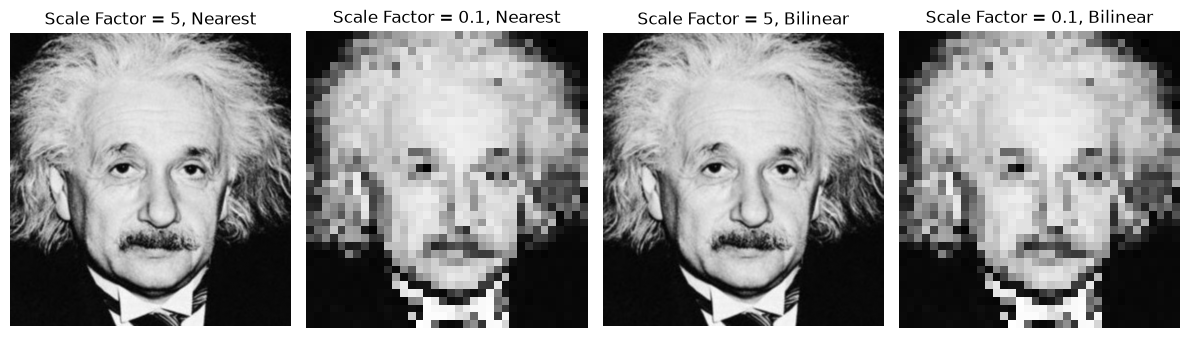

In [11]:
#Method = 1: Nearest Neighbor Interpolation, Method = 2: Bilinear Interpolation
def img_scale(im, scale_factor, method=1):

    img = cv.imread(im, cv.IMREAD_GRAYSCALE)
    assert img is not None
    h, w = img.shape
    new_h, new_w = int(h * scale_factor), int(w * scale_factor)
    output = np.zeros((new_h, new_w), dtype=np.float64)

    if method == 1:
        #Nearest neighbor interpolation
        for i in range(new_h):
            for j in range(new_w):
                x = int(i/scale_factor)
                y = int(j/scale_factor)

                output[i, j] = img[x, y]
    
    else:
        #Bilinear interpolation
        for i in range(new_h):
            for j in range(new_w):
                x = i / scale_factor
                y = j / scale_factor

                x1 = int(x)
                x2 = min(x1 + 1, h-1)
                y1 = int(y)
                y2 = min(y1 + 1, w-1)

                dx = x - x1
                dy = y - y1

                Q11 = img[x1, y1]
                Q12 = img[x1, y2]
                Q21 = img[x2, y1]
                Q22 = img[x2, y2]

                output[i, j] = (Q11 * (1 - dx) * (1 - dy) +
                                Q21 * (dx) * (1 - dy) +
                                Q12 * (1 - dx) * (dy) +
                                Q22 * (dx) * (dy))
    
    return output.astype(np.uint8)

img1 = img_scale("albert_einstein.jpg", 5, 1)
img2 = img_scale("albert_einstein.jpg", 0.1, 1)
img3 = img_scale("albert_einstein.jpg", 5, 2)
img4 = img_scale("albert_einstein.jpg", 0.1, 2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(img1, cmap='gray')
plt.title('Scale Factor = 5, Nearest')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img2, cmap='gray')
plt.title('Scale Factor = 0.1, Nearest')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img3, cmap='gray')
plt.title('Scale Factor = 5, Bilinear')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img4, cmap='gray')
plt.title('Scale Factor = 0.1, Bilinear')
plt.axis('off')

plt.tight_layout()
plt.show()

<h2 align="left">Question 9</h2>

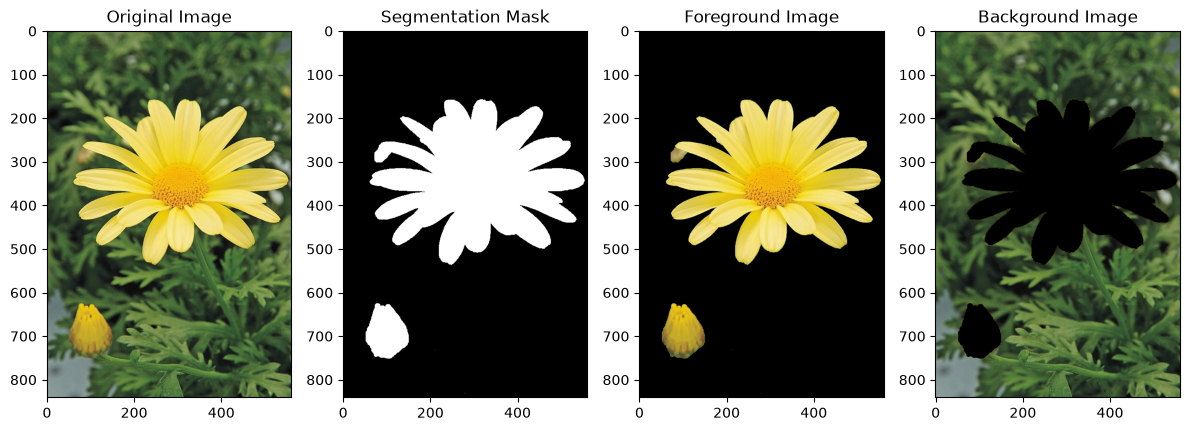

In [21]:
img_bgr = cv.imread("yellow_flower.jpg")
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)    

mask = np.zeros(img_rgb.shape[:2], np.uint8)

#This is a hardcoded requirement of OpenCV's grabCut function.
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

height, width = img_rgb.shape[:2]
#Manually defined rectangle around the object of interest 
#such that the whole flower is included in the box.
rect = (5, 5, width - 10, height - 10) 

cv.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)
mapping = np.array([0, 1, 0, 1], dtype=np.uint8)
mask = mapping[mask]
inv_mask = 1 - mask

foreground = cv.bitwise_and(img_rgb, img_rgb, mask=mask)
background = cv.bitwise_and(img_rgb, img_rgb, mask=inv_mask)

plt.figure(figsize=(12, 5))
plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Original Image')

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap='gray')
plt.title('Segmentation Mask')  

plt.subplot(1, 4, 3)
plt.imshow(foreground)
plt.title('Foreground Image')

plt.subplot(1, 4, 4)
plt.imshow(background)
plt.title('Background Image')
plt.tight_layout()
plt.show(block=False)

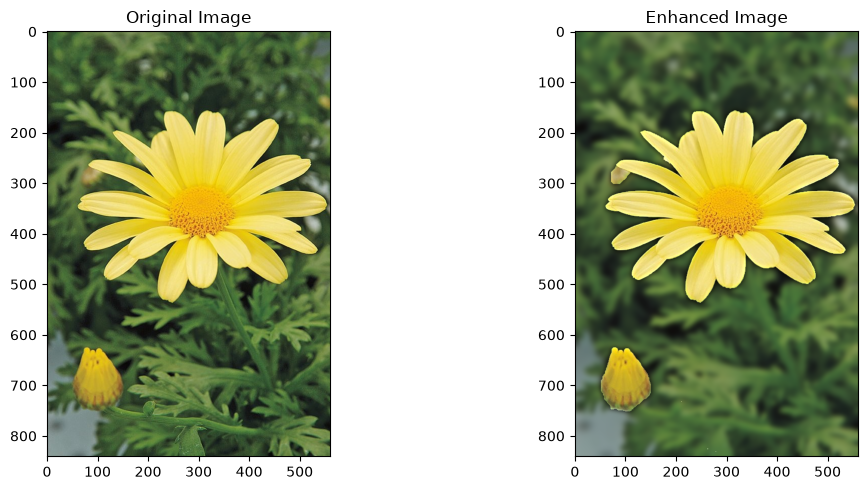

In [20]:
blurred_background = cv.GaussianBlur(background, (31, 31), 0)
enhanced_img = cv.add(foreground, blurred_background)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img)
plt.title('Enhanced Image')

plt.tight_layout()
plt.show(block=False)

**Answer for Part C:**
The background just beyond the edge of the flower is dark because of a side effect from the blurring process. Removing the foreground flower leaves a black hole (zero intensity pixels) in the background image. Then we apply a Gaussian blur to this background. The blur effect mixes the black pixels from the hole with the nearby background pixels. This mixing makes the background pixels right next to the hole much darker. Finally, we paste the sharp flower back on top.The flower covers the hole, but the darkened background pixels are still visible just outside the edges.

<h2 align="left">Question 10</h2>

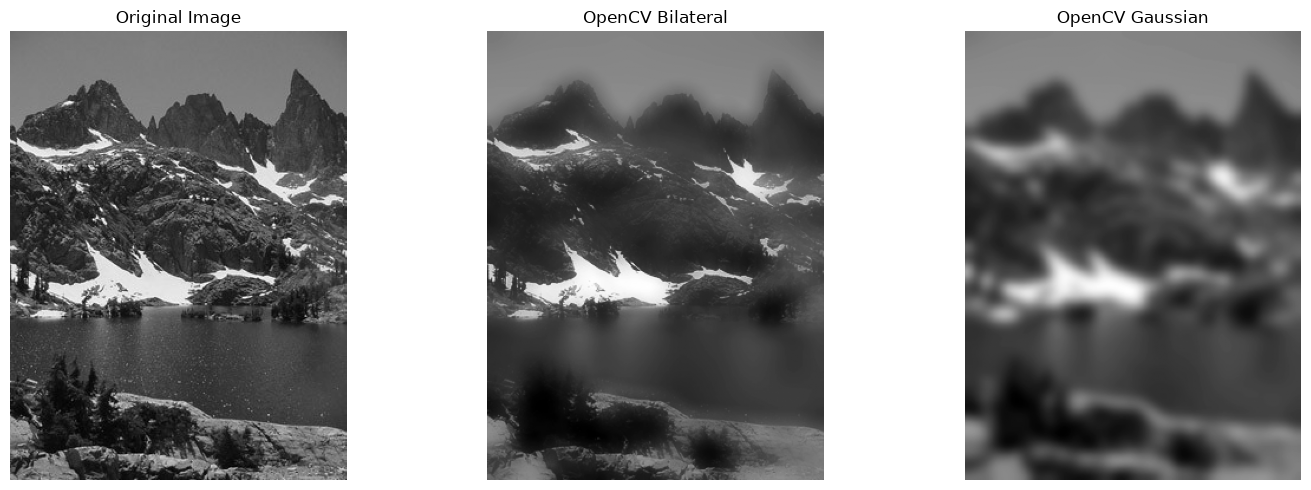

In [26]:
img = cv.imread('mountains.jpg', cv.IMREAD_GRAYSCALE)

diameter = 31
sigma_color = 75.0
sigma_space = 75.0

# (a) OpenCV's Built-in Bilateral Filter
opencv_filtered = cv.bilateralFilter(img, diameter, sigma_color, sigma_space)
Gaussian_filtered = cv.GaussianBlur(img, (diameter, diameter), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(opencv_filtered, cmap='gray')
plt.title('OpenCV Bilateral')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Gaussian_filtered, cmap='gray')
plt.title('OpenCV Gaussian')
plt.axis('off')

plt.tight_layout()
plt.show()


Mean Squared Error between Custom and OpenCV Bilateral: 3.6454


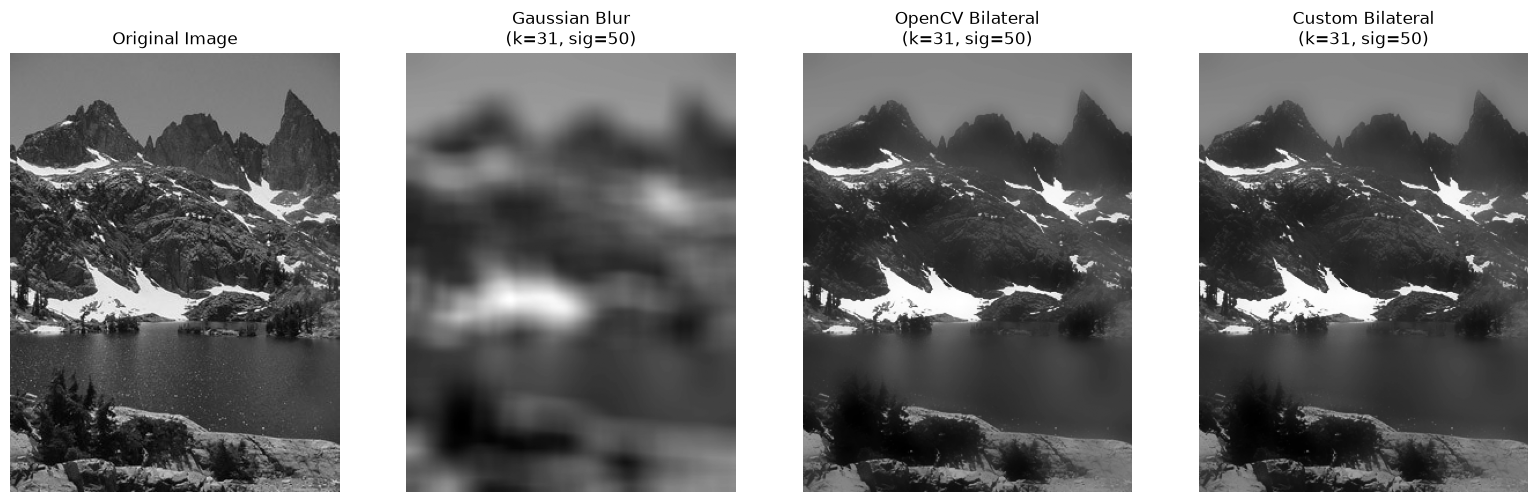

In [32]:
def bilaterl_filter(im_path, diameter, sigma_color, sigma_space):
    img = cv.imread(im_path, cv.IMREAD_GRAYSCALE)
    assert img is not None
    h, w = img.shape

    radius = diameter // 2 
    
    img_float = img.astype(np.float64)
    padded_img = np.pad(img_float, radius, mode='reflect')
    output = np.zeros((h, w), dtype=np.float64)

    x, y = np.meshgrid(np.arange(-radius, radius + 1), np.arange(-radius, radius + 1))
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_space**2))
    
    for i in range(h):
        for j in range(w):
            i_padded = i + radius
            j_padded = j + radius
            
            local_region = padded_img[i_padded - radius:i_padded + radius + 1, 
                                      j_padded - radius:j_padded + radius + 1]

            # Range Gaussian weights
            intensity_diff = local_region - img_float[i, j]
            range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_color**2))

            combined_weights = spatial_weights * range_weights
            combined_weights /= np.sum(combined_weights)

            output[i, j] = np.sum(combined_weights * local_region)

    return output.astype(np.uint8)


image_file = 'mountains.jpg' 
diameter = 31
sigma_color = 50
sigma_space = 50

original_img = cv.imread(image_file, cv.IMREAD_GRAYSCALE)
custom_filtered = bilaterl_filter(image_file, diameter, sigma_color, sigma_space)
cv_bilateral = cv.bilateralFilter(original_img, diameter, sigma_color, sigma_space)
gaussian_blurred = cv.GaussianBlur(original_img, (diameter, diameter), sigma_space)

# Quantitative Measure: Mean Squared Error (MSE)
diff = custom_filtered.astype(np.float64) - cv_bilateral.astype(np.float64)
mse = np.mean(diff ** 2)
print(f"Mean Squared Error between Custom and OpenCV Bilateral: {mse:.4f}")

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(original_img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(gaussian_blurred, cmap='gray')
plt.title(f'Gaussian Blur\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(cv_bilateral, cmap='gray')
plt.title(f'OpenCV Bilateral\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(custom_filtered, cmap='gray')
plt.title(f'Custom Bilateral\n(k={diameter}, sig={sigma_space})')
plt.axis('off')

plt.tight_layout()
plt.show()